<a href="https://colab.research.google.com/github/RoseMaryBiju/Computer-Vision-Projects/blob/unit4/Unit_4_Depth_Estimation_for_Autonomous_Driving_using_Stereo_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective**

To estimate the depth (distance) of objects in a driving scene using stereo vision — a technique where two cameras observe the same scene from slightly different angles.
This simulates how self-driving cars and robotic vision systems perceive distance and understand 3D structure.

**Concept Overview**

Stereo Vision: Two images (left & right) of the same scene are used.

Disparity: The horizontal pixel difference between corresponding points in both images.

Triangulation: Depth is inversely proportional to disparity — larger disparity → closer object.

3D Reconstruction: Using the disparity map, a 3D view (point cloud) of the scene can be generated.

**Key Topics from Syllabus**

Projection Schemes

Shape from Stereo / Depth from Disparity

Motion Triangulation

3D Reconstruction

Volumetric & Point-Based Representation

**Implementation Steps**

Load left and right stereo images.

Compute disparity map using OpenCV’s StereoBM algorithm.

Visualize the disparity → depth map using a color map.

Optionally reconstruct 3D points from disparity.

**Expected Output**

Left & Right Camera Views

Colorful Depth Map showing near objects in bright colors and far ones in dark shades.

(Optional) 3D point cloud representation of the scene.

 **Real-World Applications**

Autonomous driving (LiDAR replacement / visual depth estimation)

Robot navigation and obstacle avoidance

3D scene reconstruction and mapping (SLAM)

AR/VR depth sensing

# Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Step 1: Download working stereo image pair




In [ ]:
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeL.jpg -O left.png
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeR.jpg -O right.png


# Step 2: Load images (grayscale)


In [ ]:
left = cv2.imread("left.png", 0)
right = cv2.imread("right.png", 0)

if left is None or right is None:
    raise FileNotFoundError("Error: Could not load stereo images. Please re-run this cell.")


Display both images

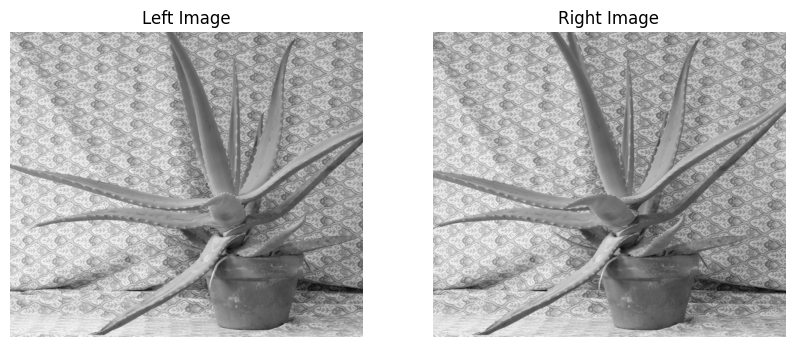

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(left, cmap='gray'); plt.title("Left Image"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(right, cmap='gray'); plt.title("Right Image"); plt.axis('off')
plt.show()

# Step 3: Compute disparity (depth)

In [ ]:
stereo = cv2.StereoBM_create(numDisparities=16*6, blockSize=15)
disparity = stereo.compute(left, right)

## Normalize disparity for display

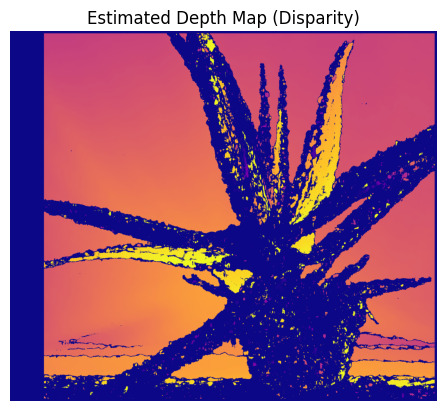

In [ ]:
disp_vis = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
disp_vis = np.uint8(disp_vis)

plt.imshow(disp_vis, cmap='plasma')
plt.title("Estimated Depth Map (Disparity)")
plt.axis('off')
plt.show()

# Step 4: Reconstruct 3D points

In [ ]:
h, w = left.shape
focal_length = 0.8 * w
Q = np.float32([[1, 0, 0, -0.5*w],
                [0,-1, 0,  0.5*h],
                [0, 0, 0, -focal_length],
                [0, 0, 1, 0]])
points_3D = cv2.reprojectImageTo3D(disparity, Q)

print("3D point cloud shape:", points_3D.shape)

3D point cloud shape: (1110, 1282, 3)
